In [6]:
# Imports
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
# from scipy import stats
# from scipy.optimize import curve_fit, fsolve
from sgp4.api import SGP4_ERRORS
from sgp4.api import Satrec, WGS84
# New Skyfield and standard library imports
from skyfield.api import load
# from scipy import stats
from datetime import timedelta
from tqdm import tqdm
# from scipy.spatial.distance import cdist

In [7]:
# Satellite class. Including 6 orbital elements to calculate position and for propogation
class Satellite:
    def __init__(self, name, a, e, i, omega, arg_peri, true_anom):
        self.name = name
        self.a = a
        self.e = e
        self.i = i
        self.omega = omega
        self.arg_peri = arg_peri
        self.true_anom = true_anom


# Satellite Constellation generator. Generate initial condition for satellite to propogate
def spacex_constellation():
    constellation = []
    satellite_id = 1

    # Core constellation
    a = 550 + 6378.137  # Semimajor axis (km)
    e = 0
    i = 53  # Inclination (deg)
    # Right ascension of the ascending node (degree)
    omega = np.linspace(0, 360, 24, endpoint=False)
    arg_peri = 0  # Argument of pericenter (rad)
    # True anomaly (degree)
    true_anom = np.linspace(0, 360, 66, endpoint=False)

    for idx in range(len(omega)):
        for anom in true_anom:
            name = f"Satellite-{satellite_id}"
            satellite = Satellite(name, a, e, i, omega[idx], arg_peri, anom)
            constellation.append(satellite)
            satellite_id += 1
    return constellation

# helper function to create field of view matrix for each satellite. 
def create_field_of_view_matrices(relative_positions_all, fov_angle, max_distance):
    """
    Creates 4 binary visibility matrices (front, behind, left, right) that encode
    which satellites are visible to each other within a directional cone (FOV)
    and within a maximum communication distance.

    Each matrix [i, j] = 1 means satellite j is visible FROM satellite i
    in that direction, and is close enough to communicate with.

    The 4 directional cones are centered at:
        Front  =   0° (direction satellite i is traveling)
        Right  =  90° (to the right of travel direction)
        Behind = 180° (opposite of travel direction)
        Left   = 270° (to the left of travel direction)

    Each cone spans ±fov_half_angle degrees around its center.

    Parameters:
    -----------
    relative_positions_all : np.ndarray, shape (N, N, 2)
        Output from calculate_relative_positions_all().
        [:, :, 0] = distances between every satellite pair (meters)
        [:, :, 1] = relative angles in each satellite's local frame (degrees, 0-360)
    fov_angle : float
        Total angular width of each directional cone in degrees.
        e.g. fov_angle=60 means each cone spans ±30° around its center direction.
    max_distance : float
        Maximum communication range in meters.
        Satellite pairs beyond this distance are excluded even if within the FOV cone.

    Returns:
    --------
    fov_matrix_front  : np.ndarray, shape (N, N), dtype=int
        [i, j] = 1 if satellite j is in satellite i's FRONT cone and within range
    fov_matrix_behind : np.ndarray, shape (N, N), dtype=int
        [i, j] = 1 if satellite j is in satellite i's BEHIND cone and within range
    fov_matrix_left   : np.ndarray, shape (N, N), dtype=int
        [i, j] = 1 if satellite j is in satellite i's LEFT cone and within range
    fov_matrix_right  : np.ndarray, shape (N, N), dtype=int
        [i, j] = 1 if satellite j is in satellite i's RIGHT cone and within range
    """
    num_satellites = len(relative_positions_all)
    fov_half_angle = fov_angle / 2
    fov_matrix_front = np.zeros((num_satellites, num_satellites), dtype=int)
    fov_matrix_behind = np.zeros((num_satellites, num_satellites), dtype=int)
    fov_matrix_left = np.zeros((num_satellites, num_satellites), dtype=int)
    fov_matrix_right = np.zeros((num_satellites, num_satellites), dtype=int)

    angles = relative_positions_all[:, :, 1]
    distances = relative_positions_all[:, :, 0]
    front_mask = (360 - fov_half_angle <= angles) | (angles < fov_half_angle)
    right_mask = (90 - fov_half_angle <= angles) & (angles < 90 + fov_half_angle)
    behind_mask = (180 - fov_half_angle <= angles) & (angles < 180 + fov_half_angle)
    left_mask = (270 - fov_half_angle <= angles) & (angles < 270 + fov_half_angle)

    fov_matrix_front[(front_mask) & (distances <= max_distance)] = 1
    fov_matrix_behind[(behind_mask) & (distances <= max_distance)] = 1
    fov_matrix_left[(left_mask) & (distances <= max_distance)] = 1
    fov_matrix_right[(right_mask) & (distances <= max_distance)] = 1

    return fov_matrix_front, fov_matrix_behind, fov_matrix_left, fov_matrix_right


def greedy_search(
    G, positions, fov_matrix_front, fov_matrix_behind, fov_matrix_left, fov_matrix_right
):
    num_satellites = len(positions)
    max_distance = 999999999999  # Use this for unreachable distances
    distance_average = []
    # Track potential connections without adding them immediately
    existing_connections = {
        i: {"front": None, "behind": None, "left": None, "right": None}
        for i in range(num_satellites)
    }

    # Identify potential connections
    for i in range(num_satellites):
        for direction, fov_matrix, opposite in zip(
            ["front", "behind", "left", "right"],
            [fov_matrix_front, fov_matrix_behind, fov_matrix_left, fov_matrix_right],
            ["behind", "front", "right", "left"],
        ):
            # Set unreachable distances to satellites not in the FOV
            distances = np.linalg.norm(positions - positions[i], axis=1)
            distances[fov_matrix[i] == 0] = max_distance

            while np.min(distances) != max_distance:

                closest_idx = np.argmin(distances)
                # print(closest_idx)
                if (
                    existing_connections[i][direction] is None
                    and existing_connections[closest_idx][opposite] is None
                ):
                    # Mark the potential connection
                    existing_connections[i][direction] = closest_idx
                    existing_connections[closest_idx][opposite] = i

                    distance_average.append(distances[closest_idx])
                    break
                else:
                    # Mark this satellite as unreachable and look for the next one
                    distances[closest_idx] = max_distance
    for satellite, connections in existing_connections.items():
        for direction, target in connections.items():
            if target is not None and not G.has_edge(satellite, target):
                G.add_edge(satellite, target)
    return G, distance_average


def find_min_degree_node(G, excluded_nodes):
    min_degree = min(G.degree(v) for v in G.nodes())
    min_degree_nodes = [
        v for v in G.nodes() if G.degree(v) == min_degree and v not in excluded_nodes
    ]
    if not min_degree_nodes:
        return None  # No suitable node found
    min_ec_node = min(min_degree_nodes, key=lambda v: extendibility_centrality(G, v))
    return min_ec_node


def find_max_distance_node(positions, start_node):
    distances = np.linalg.norm(positions - positions[start_node], axis=1)
    distances[start_node] = -np.inf
    max_distance_node = np.argmax(distances)
    return max_distance_node

def extendibility_centrality(G, node):
    neighbors = list(G.neighbors(node))
    ec = sum(G.degree(v) for v in neighbors)
    return ec

def mdmd(
    G, positions, fov_matrix_front, fov_matrix_behind, fov_matrix_left, fov_matrix_right
):
    num_satellites = len(positions)
    distance_average = []
    # Initialize existing connections with no connections
    existing_connections = {
        i: {"front": None, "behind": None, "left": None, "right": None}
        for i in range(num_satellites)
    }

    # Track nodes that cannot be connected in the current iteration
    excluded_nodes = set()

    # Iterate over each satellite to find a connection in each direction
    for i in range(num_satellites):
        # Identify the satellite with the minimum degree to start the MDMD process, excluding any that cannot be connected
        min_degree_node = find_min_degree_node(G, excluded_nodes)
        if min_degree_node is None:
            break
        # A variable to track if at least one connection was made for the min_degree_node
        connection_made = False

        # For each direction, find the farthest satellite within the FOV
        for direction, fov_matrix, opposite in zip(
            ["front", "behind", "left", "right"],
            [fov_matrix_front, fov_matrix_behind, fov_matrix_left, fov_matrix_right],
            ["behind", "front", "right", "left"],
        ):

            distances = np.linalg.norm(positions - positions[min_degree_node], axis=1)
            distances[fov_matrix[min_degree_node] == 0] = -1
            while np.max(distances) != -1:
                furthest_idx = np.argmax(distances)
                if (
                    existing_connections[min_degree_node][direction] is None
                    and existing_connections[furthest_idx][opposite] is None
                ):
                    # Mark the potential connection
                    existing_connections[min_degree_node][direction] = furthest_idx
                    existing_connections[furthest_idx][opposite] = min_degree_node
                    G.add_edge(furthest_idx, min_degree_node)
                    distance_average.append(distances[furthest_idx])
                    connection_made = True
                    break
                else:
                    # Mark this satellite as unreachable and look for the next one
                    distances[furthest_idx] = -1
        if not connection_made:
            excluded_nodes.add(min_degree_node)
    return G, distance_average



# Link adding rule (subject to change). Here using code from Jackson to fullfill the flow. 
def greedy_search_furthest(
    G, positions, fov_matrix_front, fov_matrix_behind, fov_matrix_left, fov_matrix_right
):
    """
    Builds an Inter-Satellite Link (ISL) topology by connecting each satellite
    to the FURTHEST reachable satellite in each of its 4 directional FOV cones
    (front, behind, left, right). Connecting to the furthest satellite reduces
    the total number of hops needed to cross the constellation.

    Each satellite is limited to 4 links maximum (one per direction).
    A link is only formed if BOTH satellites have their directional slot free:
        - satellite i's "front"  pairs with target's "behind"
        - satellite i's "left"   pairs with target's "right"

    Parameters:
    -----------
    G : nx.Graph
        Empty NetworkX graph with N nodes (one per satellite), no edges yet
    positions : np.ndarray, shape (N, 3)
        3D ECI positions of all satellites in meters
    fov_matrix_front : np.ndarray, shape (N, N)
        Binary matrix — fov_matrix_front[i, j] = 1 if satellite j is in
        satellite i's FRONT cone AND within max distance, else 0
    fov_matrix_behind : np.ndarray, shape (N, N)
        Same for the BEHIND direction
    fov_matrix_left : np.ndarray, shape (N, N)
        Same for the LEFT direction
    fov_matrix_right : np.ndarray, shape (N, N)
        Same for the RIGHT direction

    Returns:
    --------
    G : nx.Graph
        Graph now populated with ISL edges between connected satellites
    distance_average : list of float
        Distances (meters) of every link formed. Average gives mean ISL length.
    """
    num_satellites = len(positions)
    distance_average = []
    # Track potential connections without adding them immediately
    existing_connections = {
        i: {"front": None, "behind": None, "left": None, "right": None}
        for i in range(num_satellites)
    }

    # Identify potential connections
    for i in range(num_satellites):
        for direction, fov_matrix, opposite in zip(
            ["front", "behind", "left", "right"],
            [fov_matrix_front, fov_matrix_behind, fov_matrix_left, fov_matrix_right],
            ["behind", "front", "right", "left"],
        ):
            # Set unreachable distances to satellites not in the FOV
            distances = np.linalg.norm(positions - positions[i], axis=1)
            distances[fov_matrix[i] == 0] = -1

            # Changed from np.min(distances) to np.max(distances)
            while np.max(distances) != -1:
                # Changed from np.argmin(distances) to np.argmax(distances)
                furthest_idx = np.argmax(distances)
                if (
                    existing_connections[i][direction] is None
                    and existing_connections[furthest_idx][opposite] is None
                ):
                    # Mark the potential connection
                    existing_connections[i][direction] = furthest_idx
                    existing_connections[furthest_idx][opposite] = i
                    distance_average.append(distances[furthest_idx])
                    break
                else:
                    # Mark this satellite as unreachable and look for the next one
                    distances[furthest_idx] = -1

    # Add edges based on the final existing_connections
    for satellite, connections in existing_connections.items():
        for direction, target in connections.items():
            if target is not None and not G.has_edge(satellite, target):
                G.add_edge(satellite, target)

    return G, distance_average


# function to put the satellite constellation into network (for metric analyze, such as lambda2, resistaency, etc)
def generate_network(positions):
    num_satellites = len(positions)
    G = nx.Graph()

    # Add nodes (satellites) to the graph
    for i in range(num_satellites):
        G.add_node(i)

    return G

# function to calculate cartesian coordinate
def calculate_cartesian_coordinates(constellation_obj, t_offset_minutes):
    """
    Propagates a satellite constellation forward in time using the SGP4 orbital
    mechanics model, returning each satellite's 3D position and velocity in the
    Earth-Centered Inertial (ECI) coordinate frame.

    Parameters:
    -----------
    constellation_obj : list of Satellite
        List of Satellite objects, each containing Keplerian orbital elements
        (a, e, i, omega, arg_peri, true_anom)
    t_offset_minutes : float
        Time offset in minutes from the base epoch to propagate to.
        e.g. 0 = initial positions, 90 = 90 minutes later

    Returns:
    --------
    positions : np.ndarray, shape (N, 3)
        3D ECI position vectors for each satellite in meters [x, y, z]
    velocities : np.ndarray, shape (N, 3)
        3D ECI velocity vectors for each satellite in meters/second [vx, vy, vz]
    """
    num_satellites = len(constellation_obj)
    positions = np.zeros((num_satellites, 3))
    velocities = np.zeros((num_satellites, 3))
    
    # Earth gravitational constant (km^3/s^2) for mean motion calculation
    mu = 398600.4418
    
    # Set an arbitrary base epoch (Julian Date) for the simulation
    jd1 = 2460000.0
    jd2 = 0.0
    target_jd2 = jd2 + (t_offset_minutes / 1440.0) # Convert minutes to days
    
    for i, sat in enumerate(constellation_obj):
        # 1. Convert degrees to radians for SGP4
        inclo = np.radians(sat.i)
        nodeo = np.radians(sat.omega)
        argpo = np.radians(sat.arg_peri)
        nu = np.radians(sat.true_anom)
        ecco = sat.e
        
        # 2. Convert True Anomaly to Mean Anomaly (mo)
        if ecco < 1e-8: # Basically circular (like Starlink)
            mo = nu
        else:
            E = 2 * np.arctan(np.sqrt((1 - ecco) / (1 + ecco)) * np.tan(nu / 2))
            mo = E - ecco * np.sin(E)
            
        # 3. Calculate Mean Motion (no_kozai) in radians per minute
        n_rad_per_sec = np.sqrt(mu / (sat.a ** 3))
        no_kozai = n_rad_per_sec * 60.0
        
        # 4. Initialize the satellite natively into SGP4
        rec = Satrec()
        rec.sgp4init(
            WGS84,           # Standard gravity model
            'i',             # 'i' = improved operational mode
            i + 1,           # Satellite number
            (jd1 + jd2) - 2433281.5, # SGP4 epoch format (days since Dec 31 1949)
            0.0,             # bstar (drag term, set to 0 for pure gravity)
            0.0,             # ndot
            0.0,             # nddot
            ecco,            # Eccentricity
            argpo,           # Argument of perigee (rad)
            inclo,           # Inclination (rad)
            mo,              # Mean anomaly (rad)
            no_kozai,        # Mean motion (rad/min)
            nodeo            # Right ascension of ascending node (rad)
        )
        
        # 5. Propagate the orbit using standard SGP4
        error_code, r, v = rec.sgp4(jd1, target_jd2)
        
        if error_code == 0:
            positions[i, :] = np.array(r) * 1000.0  # Convert km to meters
            velocities[i, :] = np.array(v) * 1000.0 # Convert km/s to meters/s
        else:
            print(f"SGP4 Propagation error {error_code} for satellite {sat.name}")
            
    return positions, velocities


def calculate_relative_positions_all(positions, headings):
    """
    Calculates the relative distance and angle from every satellite to every 
    other satellite, expressed in each satellite's own local reference frame.
    
    Parameters:
    -----------
    positions : np.ndarray, shape (N, 3)
        3D Cartesian positions of all N satellites in ECI frame (meters)
    headings : np.ndarray, shape (N,)
        Heading/facing direction of each satellite in degrees (0-360),
        derived from its velocity vector
    
    Returns:
    --------
    relative_positions_all : np.ndarray, shape (N, N, 2)
        3D array where:
        - relative_positions_all[i, j, 0] = distance from satellite i to satellite j (meters)
        - relative_positions_all[i, j, 1] = angle to satellite j as seen FROM satellite i's 
                                             local frame (degrees, 0-360)
    """
    num_satellites = len(positions)
    relative_positions_all = np.zeros((num_satellites, num_satellites, 2))

    for i in range(num_satellites):
        diffs = positions - positions[i]
        distances = np.linalg.norm(diffs, axis=1)
        angles = np.degrees(np.arctan2(diffs[:, 1], diffs[:, 0]))
        relative_angles = angles - headings[i]
        relative_angles = (relative_angles + 360) % 360
        relative_positions_all[i, :, 0] = distances
        relative_positions_all[i, :, 1] = relative_angles
    return relative_positions_all

In [ ]:
"""Predictive ISL link formation as a matching game.

This implements the policy described in the project writeups: at each epoch every
satellite scores its feasible neighbors by the single-edge marginal of
``log tau`` minus a slewing cost, and links are realized by a **stable matching**
(deferred acceptance) rather than a one-shot optimistic pick. Matching directly
realizes the mutual-choice rule and avoids the wasted-terminal reciprocation
failure of a single synchronous round.

Per terminal, satellite ``i`` ranks candidate ``j`` by

    score_i(j) = log(1 + R_ij) - alpha * angle(theta_i^prev, theta_ij),

where ``R_ij`` is the effective resistance between ``i`` and ``j`` estimated
locally on the union of ``i``'s and ``j``'s h-hop neighborhoods in the windowed
union graph ``G_union`` (measured BEFORE the edge is added -- the exact marginal
of log #spanning-trees). Terminals pair up by direction (front<->behind,
left<->right); each is a stable matching, so realized degree never exceeds 4.
"""

from collections import deque

import networkx as nx
import numpy as np

_DIRECTIONS = ["front", "behind", "left", "right"]
_OPPOSITE = {"front": "behind", "behind": "front", "left": "right", "right": "left"}
# The two independent matchings: (proposer direction, receiver direction).
_DIRECTION_PAIRS = [("front", "behind"), ("left", "right")]


def _slew_fraction(angle_prev, cand_angle):
    """Normalized angular repointing distance in [0, 1] (0 if no prior pointing)."""
    if angle_prev is None:
        return 0.0
    diff = abs(cand_angle - angle_prev)
    diff = min(diff, 360.0 - diff)
    return diff / 180.0


def _gale_shapley(proposer_pref, receiver_score):
    """Deferred-acceptance stable matching (capacity 1 on both sides).

    Parameters
    ----------
    proposer_pref : dict[int, list[int]]
        proposer -> receivers in descending preference order.
    receiver_score : callable(receiver, proposer) -> comparable
        Higher is better; used by each receiver to compare its suitors.

    Returns
    -------
    dict[int, int]
        receiver -> matched proposer.
    """
    held = {}        # receiver -> proposer
    held_score = {}  # receiver -> score of held proposer
    nxt = {p: 0 for p in proposer_pref}
    free = deque(p for p in proposer_pref if proposer_pref[p])

    while free:
        p = free.popleft()
        prefs = proposer_pref[p]
        while nxt[p] < len(prefs):
            r = prefs[nxt[p]]
            nxt[p] += 1
            sc = receiver_score(r, p)
            if r not in held:
                held[r] = p
                held_score[r] = sc
                break
            if sc > held_score[r]:
                bumped = held[r]
                held[r] = p
                held_score[r] = sc
                if nxt[bumped] < len(proposer_pref[bumped]):
                    free.append(bumped)
                break
            # else: rejected, try next preference
    return held


def game_theory_formation(
    G,
    positions,
    relative_positions,
    fov_matrix_front,
    fov_matrix_behind,
    fov_matrix_left,
    fov_matrix_right,
    G_prev=None,
    G_union=None,
    alpha=0.5,
    bridge_bonus=1e3,
    est_radius=3,
):
    """Form one epoch's ISL topology as a stable matching game.

    Parameters
    ----------
    G : nx.Graph
        Empty graph on the N satellite nodes; populated and returned.
    G_prev : nx.Graph or None
        Previous epoch's realized graph (for slewing cost). None at t=0.
    G_union : nx.Graph or None
        Windowed union graph G^cup(t; T); connectivity context for the marginal.
        None/empty at t=0, so every candidate bridges two components.
    alpha : float
        Slewing-cost weight.
    bridge_bonus : float
        Finite score for a pair the local estimate cannot connect (different
        components of the local subgraph) -- large enough to dominate any
        in-component marginal, finite so slewing/proximity break ties.
    est_radius : int
        Hop radius of each satellite's local neighborhood used to estimate R_ij.
    """
    num_satellites = len(positions)

    fov_map = {
        "front": fov_matrix_front,
        "behind": fov_matrix_behind,
        "left": fov_matrix_left,
        "right": fov_matrix_right,
    }

    # --- Feasible, mutually visible candidates per (satellite, direction) ---
    candidates = {i: {d: [] for d in _DIRECTIONS} for i in range(num_satellites)}
    for i in range(num_satellites):
        for direction in _DIRECTIONS:
            fov = fov_map[direction]
            fov_opposite = fov_map[_OPPOSITE[direction]]
            for j in range(num_satellites):
                if (i != j) and (fov[i, j] == 1) and (fov_opposite[j, i] == 1):
                    candidates[i][direction].append(j)

    if G_union is None:
        G_union = nx.Graph()
        G_union.add_nodes_from(range(num_satellites))

    # --- Current terminal pointing per (satellite, direction), from G_prev ---
    # angle_prev[(i, direction)] = bearing of last epoch's neighbor in that
    # direction (None if none). The per-endpoint "dir" dict disambiguates the
    # undirected edge.
    angle_prev = {}
    if G_prev is not None:
        for i in range(num_satellites):
            if not G_prev.has_node(i):
                continue
            for nbr in G_prev.neighbors(i):
                edge_dir = G_prev[i][nbr].get("dir", {})
                d = edge_dir.get(i)
                if d is not None:
                    angle_prev[(i, d)] = relative_positions[i, nbr, 1]

    # --- Local effective-resistance estimate (cached per unordered pair) ---
    ego_cache = {}
    marginal_cache = {}

    def ego(i):
        s = ego_cache.get(i)
        if s is None:
            s = set(nx.ego_graph(G_union, i, radius=est_radius, undirected=True))
            ego_cache[i] = s
        return s

    def marginal(i, j):
        """log(1 + R_ij) on the union of i's and j's neighborhoods; bridge bonus
        if the local view cannot connect them."""
        key = (i, j) if i < j else (j, i)
        val = marginal_cache.get(key)
        if val is not None:
            return val
        H = G_union.subgraph(ego(i) | ego(j))
        comp = nx.node_connected_component(H, i)
        if j in comp:
            Hc = H.subgraph(comp).copy()
            val = float(np.log1p(nx.resistance_distance(Hc, i, j)))
        else:
            val = bridge_bonus  # pair bridges two (locally visible) components
        marginal_cache[key] = val
        return val

    # --- Two stable matchings: front<->behind and left<->right ---
    for pdir, rdir in _DIRECTION_PAIRS:
        # Proposer preference lists (best first); tie-break by proximity.
        proposer_pref = {}
        for i in range(num_satellites):
            cand = candidates[i][pdir]
            if not cand:
                continue
            a_prev = angle_prev.get((i, pdir))

            def p_key(j, i=i, a_prev=a_prev):
                score = marginal(i, j) - alpha * _slew_fraction(
                    a_prev, relative_positions[i, j, 1]
                )
                return (score, -relative_positions[i, j, 0])

            proposer_pref[i] = sorted(cand, key=p_key, reverse=True)

        # Receiver scoring: receiver r ranks suitor p by its own utility.
        def receiver_score(r, p):
            a_prev = angle_prev.get((r, rdir))
            score = marginal(p, r) - alpha * _slew_fraction(
                a_prev, relative_positions[r, p, 1]
            )
            return (score, -relative_positions[r, p, 0])

        matched = _gale_shapley(proposer_pref, receiver_score)
        for r, p in matched.items():
            G.add_edge(p, r, dir={p: pdir, r: rdir})

    return G


In [9]:



# dist = 2000000
# iterations = []
# constellation_size = 1600
# constellation = spacex_constellation()
# # times = np.linspace(0, 24 * 60 * 7, 10)
# times = np.linspace(0, 1, 7)  # 0 to 60 minutes, every 0.5 minutes (30 seconds)
# G_list = []
# lambda_2_list = []
# resistance_list = []
# num_of_spanning_tree = []

# lambda_2_list_furthest = []
# resistance_list_furthest = []
# num_of_spanning_tree = []
# G_prev = None  # <-- initialize before the loop

# for t in tqdm(times, desc="Simulating timesteps"):
#     # Propagate the satellite constellation, obtain positions.
#     positions, velocities = calculate_cartesian_coordinates(constellation, t)
#     headings = np.degrees(np.arctan2(velocities[:, 1], velocities[:, 0]))
#     headings = (headings + 360) % 360
#     relative_positions_all = calculate_relative_positions_all(positions, headings)

#     fov_angle = 60
#     max_distance = int(dist)
#     fov_matrix_front, fov_matrix_behind, fov_matrix_left, fov_matrix_right = (
#         create_field_of_view_matrices(relative_positions_all, fov_angle, max_distance)
#     )
#     np.fill_diagonal(fov_matrix_front, 0)
#     np.fill_diagonal(fov_matrix_behind, 0)
#     np.fill_diagonal(fov_matrix_left, 0)
#     np.fill_diagonal(fov_matrix_right, 0)

#     # Generate empty base network
#     G = generate_network(positions)
    
#     G_result, distance_at_t = greedy_search_furthest(
#             G.copy(),
#             positions,
#             fov_matrix_front,
#             fov_matrix_behind,
#             fov_matrix_left,
#             fov_matrix_right,
#     )

#     # Execute game-theory link selection, passing G_prev for slewing cost
#     G_game = game_theory_formation(
#         G.copy(),
#         positions,
#         relative_positions_all,
#         fov_matrix_front,
#         fov_matrix_behind,
#         fov_matrix_left,
#         fov_matrix_right,
#         G_prev=G_prev,        # <-- None on first step, previous result thereafter
#     )

#     G_prev = G_game           # <-- store result for next timestep

#     G_list.append(G_game)
#     lambda_2_list.append(nx.algebraic_connectivity(G_game))
#     lambda_2_list_furthest.append(nx.algebraic_connectivity(G_result))
#     resistance_list.append(nx.effective_graph_resistance(G_game))
#     resistance_list_furthest.append(nx.effective_graph_resistance(G_result))
#     num_of_spanning_tree.append(np.log(nx.number_of_spanning_trees(G_game)))
    

In [ ]:
dist = 3000000
iterations = []
constellation_size = 1600
constellation = spacex_constellation()
# times = np.linspace(0, 24 * 60 * 7, 10)
times = np.linspace(0, 1, 7)  # 0 to 60 minutes, every 0.5 minutes (30 seconds)
G_game_list = []
G_furthest_list = []
G_greedy_list = []
G_mdmd_list = []

lambda_2_game_list = []
resistance_game_list = []

lambda_2_list_furthest = []
resistance_list_furthest = []

# lambda_2_list_greedy = []
# resistance_list_greedy = []

# lambda_2_list_mdmd = []
# resistance_list_mdmd = []

# num_of_spanning_tree = []
G_prev = None  # <-- initialize before the loop



# --- Phase 1: Precompute trajectories ---
trajectory = []  # list of dicts, one per timestep
# times = np.linspace(0, 1, 7)  # 0 to 60 minutes, every 0.5 minutes (30 seconds)
for t in tqdm(times, desc="Propagating trajectories"):
    positions, velocities = calculate_cartesian_coordinates(constellation, t)
    headings = np.degrees(np.arctan2(velocities[:, 1], velocities[:, 0]))
    headings = (headings + 360) % 360
    relative_positions_all = calculate_relative_positions_all(positions, headings)
    fov_angle = 60
    max_distance = int(dist)
    fov_matrix_front, fov_matrix_behind, fov_matrix_left, fov_matrix_right = (
        create_field_of_view_matrices(relative_positions_all, fov_angle, max_distance)
    )
    np.fill_diagonal(fov_matrix_front, 0)
    np.fill_diagonal(fov_matrix_behind, 0)
    np.fill_diagonal(fov_matrix_left, 0)
    np.fill_diagonal(fov_matrix_right, 0)

    trajectory.append({
        "positions": positions,
        "relative_positions": relative_positions_all,
        "fov_front":   fov_matrix_front,
        "fov_behind":  fov_matrix_behind,
        "fov_left":    fov_matrix_left,
        "fov_right":   fov_matrix_right,
    })

# --- Phase 2: Run simulation using precomputed data ---
G_prev = None
window = 10                # windowed-union horizon T (epochs); past epochs are fixed
game_history = []          # realized game graphs over the window, most recent last

for snap in tqdm(trajectory, desc="Simulating network"):
    G = generate_network(snap["positions"])

    G_furthest, _ = greedy_search_furthest(
        G.copy(),
        snap["positions"],
        snap["fov_front"], snap["fov_behind"],
        snap["fov_left"],  snap["fov_right"],
    )

    # G_greedy, _= greedy_search(
    #     G.copy(),
    #     snap["positions"],
    #     snap["fov_front"], snap["fov_behind"],
    #     snap["fov_left"],  snap["fov_right"],
    # )

    # G_mdmd, _ = mdmd(
    #     G.copy(),
    #     snap["positions"],
    #     snap["fov_front"], snap["fov_behind"],
    #     snap["fov_left"],  snap["fov_right"],
    # )

    # Windowed union G^cup(t; T): union of the last `window` realized game
    # graphs. This fixed graph is the connectivity context every satellite
    # best-responds against, so the round is simultaneous and order-independent.
    G_union = generate_network(snap["positions"])
    for G_past in game_history[-window:]:
        G_union.add_edges_from(G_past.edges())

    G_game = game_theory_formation(
        G.copy(),
        snap["positions"],
        snap["relative_positions"],
        snap["fov_front"], snap["fov_behind"],
        snap["fov_left"],  snap["fov_right"],
        G_prev=G_prev,
        G_union=G_union,
    )

    G_prev = G_game
    game_history.append(G_game)

    G_game_list.append(G_game)
    G_furthest_list.append(G_furthest)
    # G_greedy_list.append(G_greedy)
    # G_mdmd_list.append(G_mdmd)

    # lambda_2_list.append(nx.algebraic_connectivity(G_game))
    # lambda_2_list_furthest.append(nx.algebraic_connectivity(G_result))
    # resistance_list.append(nx.effective_graph_resistance(G_game))
    # resistance_list_furthest.append(nx.effective_graph_resistance(G_result))
    # num_of_spanning_tree.append(np.log(nx.number_of_spanning_trees(G_game)))


In [ ]:
for G_game, G_fut in tqdm(
    zip(G_game_list, G_furthest_list),
    total=len(G_game_list),
    desc="Computing metrics"
):
    lambda_2_game_list.append(nx.algebraic_connectivity(G_game))
    resistance_game_list.append(nx.effective_graph_resistance(G_game))

    lambda_2_list_furthest.append(nx.algebraic_connectivity(G_fut))
    resistance_list_furthest.append(nx.effective_graph_resistance(G_fut))

    # lambda_2_list_greedy.append(nx.algebraic_connectivity(G_grd))
    # resistance_list_greedy.append(nx.effective_graph_resistance(G_grd))

    # lambda_2_list_mdmd.append(nx.algebraic_connectivity(G_md))
    # resistance_list_mdmd.append(nx.effective_graph_resistance(G_md))

Computing metrics:   0%|          | 0/7 [00:00<?, ?it/s]

Computing metrics: 100%|██████████| 7/7 [00:18<00:00,  2.66s/it]


In [ ]:
len(lambda_2_list_furthest)

7

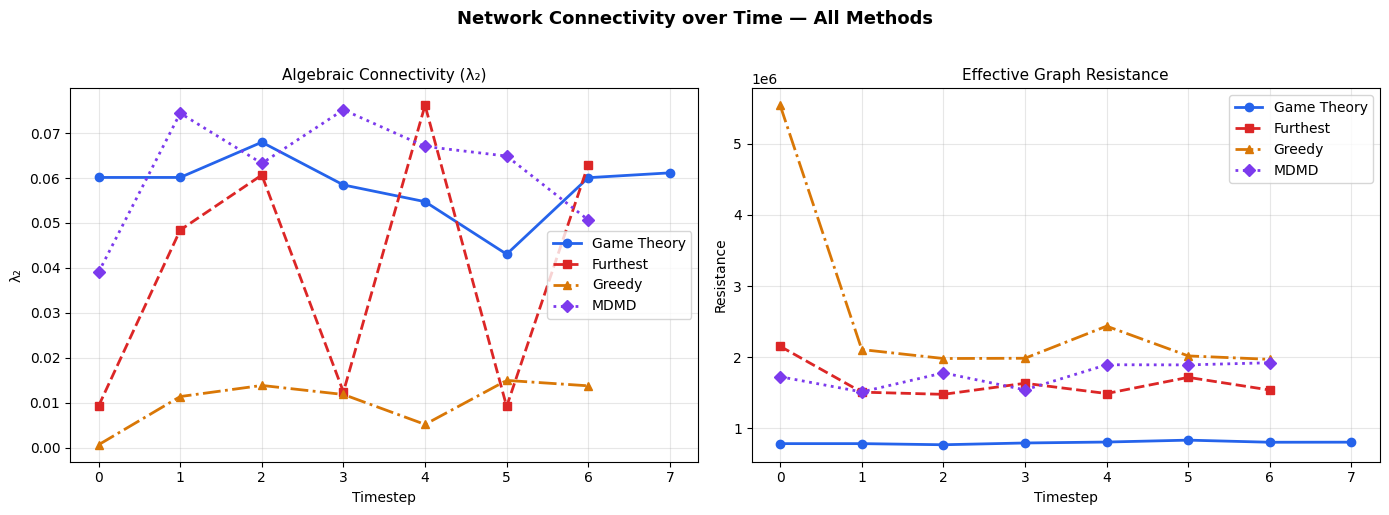

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Network Connectivity over Time — All Methods",
             fontsize=13, fontweight="bold", y=1.02)

# Separate time labels per method to handle mismatched lengths
methods = [
    ("Game Theory", lambda_2_game_list,      resistance_game_list,      "#2563eb", "o", "-"),
    ("Furthest",    lambda_2_list_furthest,  resistance_list_furthest,  "#dc2626", "s", "--"),
    # ("Greedy",      lambda_2_list_greedy,    resistance_list_greedy,    "#d97706", "^", "-."),
    # ("MDMD",        lambda_2_list_mdmd,      resistance_list_mdmd,      "#7c3aed", "D", ":"),
]

# --- Plot 1: Algebraic Connectivity (λ₂) ---
ax1 = axes[0]
for label, lambda_2, _, color, marker, linestyle in methods:
    t = np.arange(len(lambda_2))  # index based on each list's own length
    ax1.plot(t, lambda_2, marker=marker, label=label,
             color=color, linewidth=2, linestyle=linestyle)
ax1.set_title("Algebraic Connectivity (λ₂)", fontsize=11)
ax1.set_xlabel("Timestep")
ax1.set_ylabel("λ₂")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Effective Graph Resistance ---
ax2 = axes[1]
for label, _, resistance, color, marker, linestyle in methods:
    t = np.arange(len(resistance))
    ax2.plot(t, resistance, marker=marker, label=label,
             color=color, linewidth=2, linestyle=linestyle)
ax2.set_title("Effective Graph Resistance", fontsize=11)
ax2.set_xlabel("Timestep")
ax2.set_ylabel("Resistance")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_all_methods.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# fig.suptitle("Game Theory vs Greedy Furthest — Network Connectivity over Time",
#              fontsize=13, fontweight="bold", y=1.02)

# # time_labels = np.round(times / 60, 1)  # minutes → hours if preferred; here in minutes
# # times is in minutes, so use directly
# time_labels = np.round(times, 1)  # already in minutes

# # then update axis label
# ax1.set_xlabel("Time (minutes)")
# ax2.set_xlabel("Time (minutes)")
# # --- Plot 1: Algebraic Connectivity (λ₂) ---
# ax1 = axes[0]
# ax1.plot(time_labels, lambda_2_list,         marker="o", label="Game Theory",     color="#2563eb", linewidth=2)
# ax1.plot(time_labels, lambda_2_list_furthest, marker="s", label="Greedy Furthest", color="#dc2626", linewidth=2, linestyle="--")
# ax1.set_title("Algebraic Connectivity (λ₂)", fontsize=11)
# ax1.set_xlabel("Time (minutes)")
# ax1.set_ylabel("λ₂")
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# # --- Plot 2: Effective Graph Resistance ---
# ax2 = axes[1]
# ax2.plot(time_labels, resistance_list,     marker="o", label="Game Theory",     color="#2563eb", linewidth=2)
# ax2.plot(time_labels, resistance_list_furthest, marker="s", label="Greedy Furthest", color="#dc2626", linewidth=2, linestyle="--")
# ax2.set_title("Effective Graph Resistance", fontsize=11)
# ax2.set_xlabel("Time (minutes)")
# ax2.set_ylabel("Resistance")
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig("comparison_game_vs_greedy.png", dpi=150, bbox_inches="tight")
# plt.show()

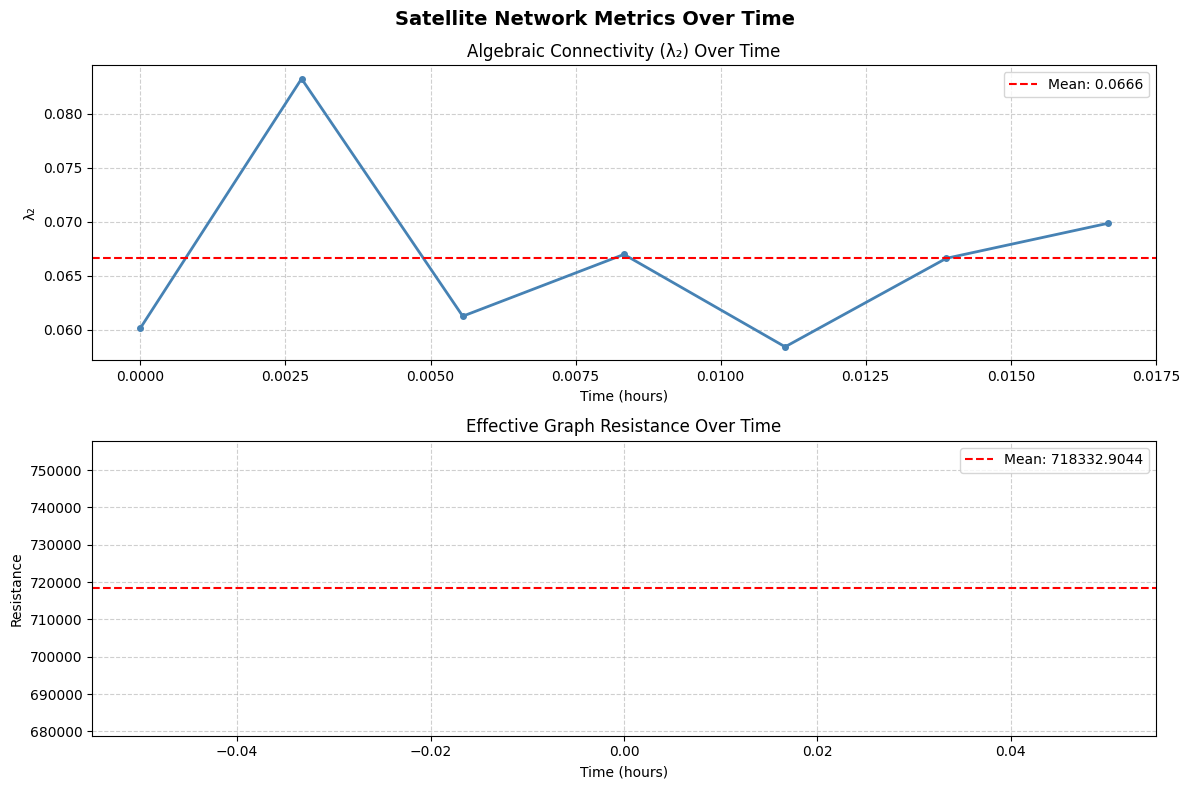

In [ ]:
# # Plotting code. 

# # Convert time from minutes to hours for readable x-axis
# times_hours = times / 60

# fig, axes = plt.subplots(2, 1, figsize=(12, 8))
# fig.suptitle('Satellite Network Metrics Over Time', fontsize=14, fontweight='bold')

# # --- Plot 1: Algebraic Connectivity (Lambda 2) ---
# axes[0].plot(times_hours, lambda_2_list, color='steelblue', linewidth=2, marker='o', markersize=4)
# axes[0].set_title('Algebraic Connectivity (λ₂) Over Time')
# axes[0].set_xlabel('Time (hours)')
# axes[0].set_ylabel('λ₂')
# axes[0].grid(True, linestyle='--', alpha=0.6)
# axes[0].axhline(y=np.mean(lambda_2_list), color='red', linestyle='--', 
#                 label=f'Mean: {np.mean(lambda_2_list):.4f}')
# axes[0].legend()

# # --- Plot 2: Effective Graph Resistance ---
# axes[1].plot(times_hours, num_of_spanning_tree, color='darkorange', linewidth=2, marker='o', markersize=4)
# axes[1].set_title('Effective Graph Resistance Over Time')
# axes[1].set_xlabel('Time (hours)')
# axes[1].set_ylabel('Resistance')
# axes[1].grid(True, linestyle='--', alpha=0.6)
# axes[1].axhline(y=np.mean(resistance_list), color='red', linestyle='--',
#                 label=f'Mean: {np.mean(resistance_list):.4f}')
# axes[1].legend()

# plt.tight_layout()
# # plt.savefig('network_metrics_over_time.png', dpi=150, bbox_inches='tight')
# plt.show()



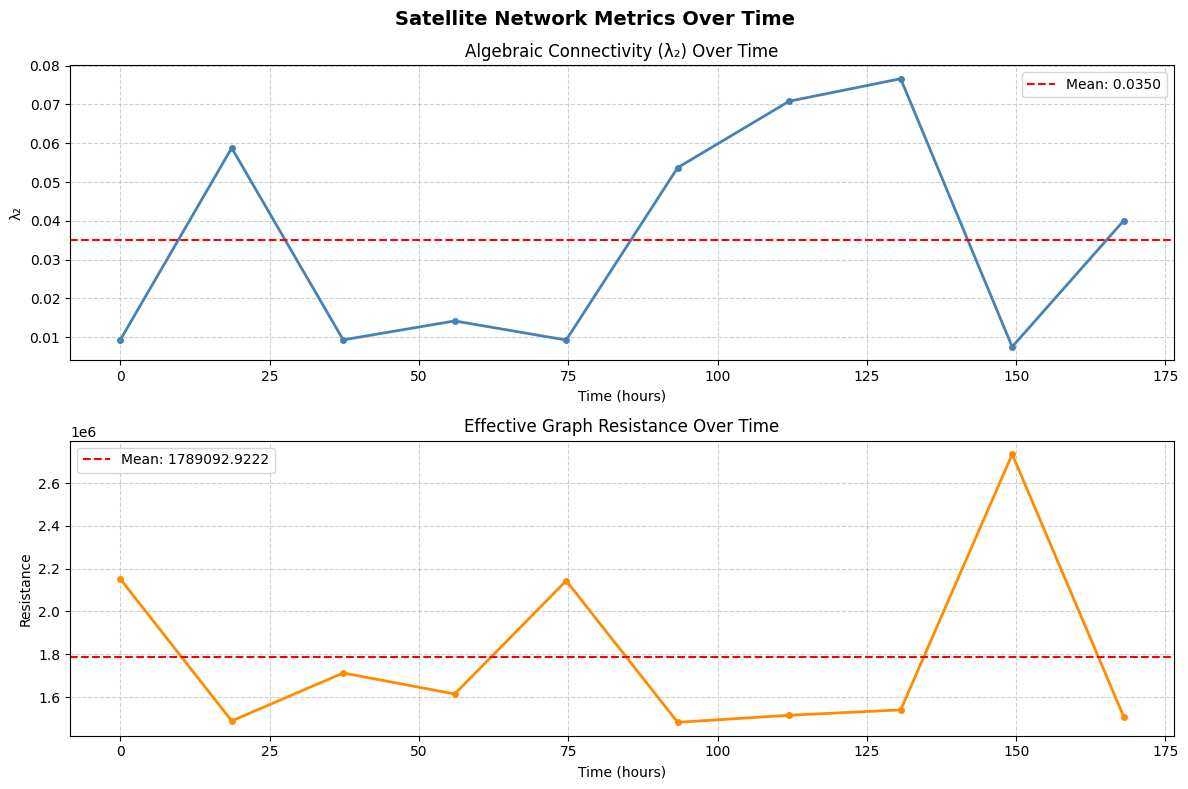

In [ ]:
# # Plotting code. 

# # Convert time from minutes to hours for readable x-axis
# times_hours = times / 60

# fig, axes = plt.subplots(2, 1, figsize=(12, 8))
# fig.suptitle('Satellite Network Metrics Over Time', fontsize=14, fontweight='bold')

# # --- Plot 1: Algebraic Connectivity (Lambda 2) ---
# axes[0].plot(times_hours, lambda_2_list, color='steelblue', linewidth=2, marker='o', markersize=4)
# axes[0].set_title('Algebraic Connectivity (λ₂) Over Time')
# axes[0].set_xlabel('Time (hours)')
# axes[0].set_ylabel('λ₂')
# axes[0].grid(True, linestyle='--', alpha=0.6)
# axes[0].axhline(y=np.mean(lambda_2_list), color='red', linestyle='--', 
#                 label=f'Mean: {np.mean(lambda_2_list):.4f}')
# axes[0].legend()

# # --- Plot 2: Effective Graph Resistance ---
# axes[1].plot(times_hours, resistance_list, color='darkorange', linewidth=2, marker='o', markersize=4)
# axes[1].set_title('Effective Graph Resistance Over Time')
# axes[1].set_xlabel('Time (hours)')
# axes[1].set_ylabel('Resistance')
# axes[1].grid(True, linestyle='--', alpha=0.6)
# axes[1].axhline(y=np.mean(resistance_list), color='red', linestyle='--',
#                 label=f'Mean: {np.mean(resistance_list):.4f}')
# axes[1].legend()

# plt.tight_layout()
# # plt.savefig('network_metrics_over_time.png', dpi=150, bbox_inches='tight')
# plt.show()



t=  0 | edges in union: 2490 | λ₂: 0.0093
t=  1 | edges in union: 4593 | λ₂: 0.2309
t=  2 | edges in union: 6444 | λ₂: 0.3795
t=  3 | edges in union: 8013 | λ₂: 0.4785
t=  4 | edges in union: 9564 | λ₂: 0.6249
t=  5 | edges in union: 11135 | λ₂: 0.7179
t=  6 | edges in union: 12523 | λ₂: 0.8677
t=  7 | edges in union: 13598 | λ₂: 0.9466
t=  8 | edges in union: 14915 | λ₂: 1.0862
t=  9 | edges in union: 16163 | λ₂: 1.1795


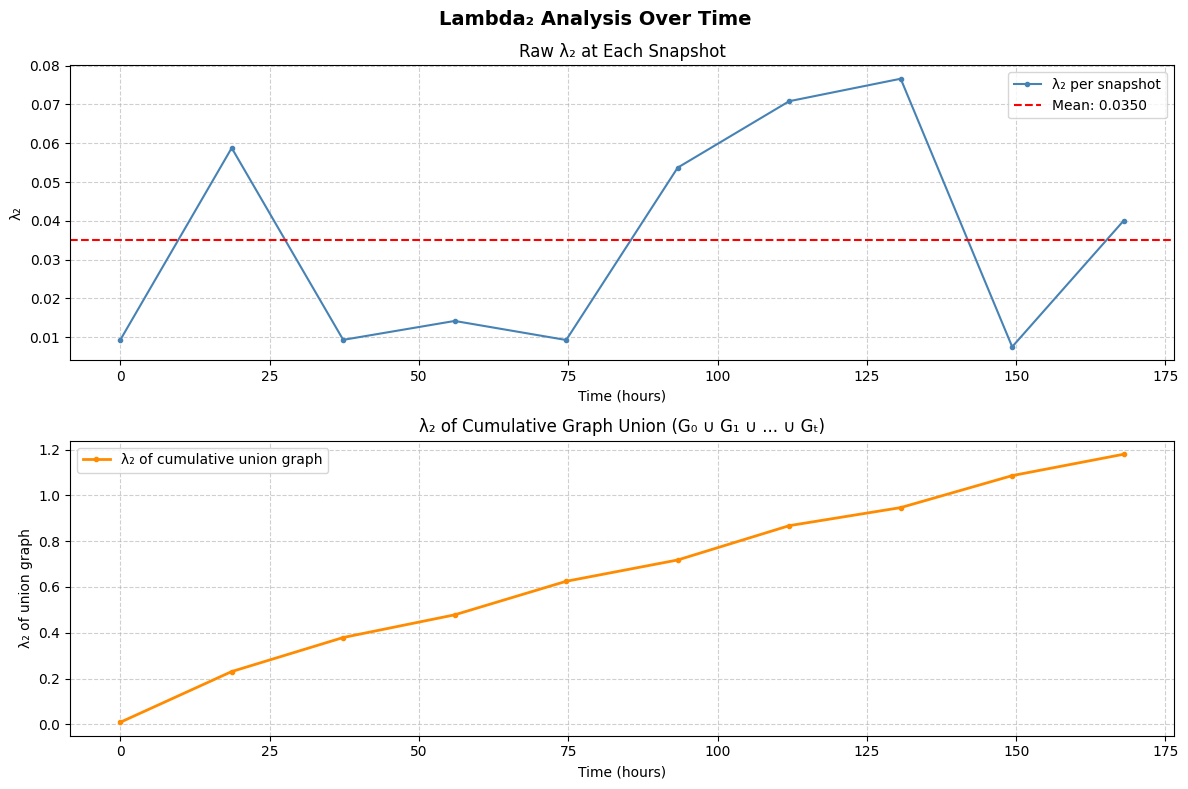


Final union graph — edges: 16163 | λ₂: 1.1795
λ₂ of union monotonically increases: True


In [ ]:


# # Time axis in hours
# times_hours = times / 60

# # ---------------------------------------------------------------
# # 1. Cumulative Graph Union Lambda_2 Over Time
# #    At each step t, compute lambda_2 of G_0 ∪ G_1 ∪ ... ∪ G_t
# # ---------------------------------------------------------------
# cumulative_union_lambda2 = []
# G_union = G_list[0].copy()   # start with the first graph

# for i, G in enumerate(G_list):
#     if i == 0:
#         # First graph — union is just G_0 itself
#         cumulative_union_lambda2.append(nx.algebraic_connectivity(G_union))
#     else:
#         # Add all edges from G_t into the running union graph
#         G_union.add_edges_from(G.edges())
#         cumulative_union_lambda2.append(nx.algebraic_connectivity(G_union))

#     print(f"t={i:3d} | edges in union: {G_union.number_of_edges()} | λ₂: {cumulative_union_lambda2[-1]:.4f}")

# # ---------------------------------------------------------------
# # Plotting
# # ---------------------------------------------------------------
# fig, axes = plt.subplots(2, 1, figsize=(12, 8))
# fig.suptitle('Lambda₂ Analysis Over Time', fontsize=14, fontweight='bold')

# # --- Plot 1: Raw Lambda_2 per snapshot ---
# axes[0].plot(times_hours, lambda_2_list, color='steelblue', linewidth=1.5,
#              marker='o', markersize=3, label='λ₂ per snapshot')
# axes[0].axhline(np.mean(lambda_2_list), color='red', linestyle='--',
#                 label=f'Mean: {np.mean(lambda_2_list):.4f}')
# axes[0].set_title('Raw λ₂ at Each Snapshot')
# axes[0].set_xlabel('Time (hours)')
# axes[0].set_ylabel('λ₂')
# axes[0].legend()
# axes[0].grid(True, linestyle='--', alpha=0.6)

# # --- Plot 2: Cumulative Union Lambda_2 ---
# axes[1].plot(times_hours, cumulative_union_lambda2, color='darkorange', linewidth=2,
#              marker='o', markersize=3, label='λ₂ of cumulative union graph')
# axes[1].set_title('λ₂ of Cumulative Graph Union (G₀ ∪ G₁ ∪ ... ∪ Gₜ)')
# axes[1].set_xlabel('Time (hours)')
# axes[1].set_ylabel('λ₂ of union graph')
# axes[1].legend()
# axes[1].grid(True, linestyle='--', alpha=0.6)

# plt.tight_layout()
# # plt.savefig('lambda2_union.png', dpi=150, bbox_inches='tight')
# plt.show()

# # ---------------------------------------------------------------
# # Summary
# # ---------------------------------------------------------------
# print(f"\nFinal union graph — edges: {G_union.number_of_edges()} | λ₂: {cumulative_union_lambda2[-1]:.4f}")
# print(f"λ₂ of union monotonically increases: {all(x <= y for x, y in zip(cumulative_union_lambda2, cumulative_union_lambda2[1:]))}")

Time step: 1120.00 min | Window size: 2 snapshots = 1 hr


Window [0:2] | edges: 4593 | λ₂: 0.2309
Window [1:3] | edges: 4715 | λ₂: 0.2473
Window [2:4] | edges: 4577 | λ₂: 0.2368
Window [3:5] | edges: 4438 | λ₂: 0.2202
Window [4:6] | edges: 4581 | λ₂: 0.2258
Window [5:7] | edges: 4618 | λ₂: 0.2354
Window [6:8] | edges: 4381 | λ₂: 0.2243
Window [7:9] | edges: 4474 | λ₂: 0.2275
Window [8:10] | edges: 4582 | λ₂: 0.2308


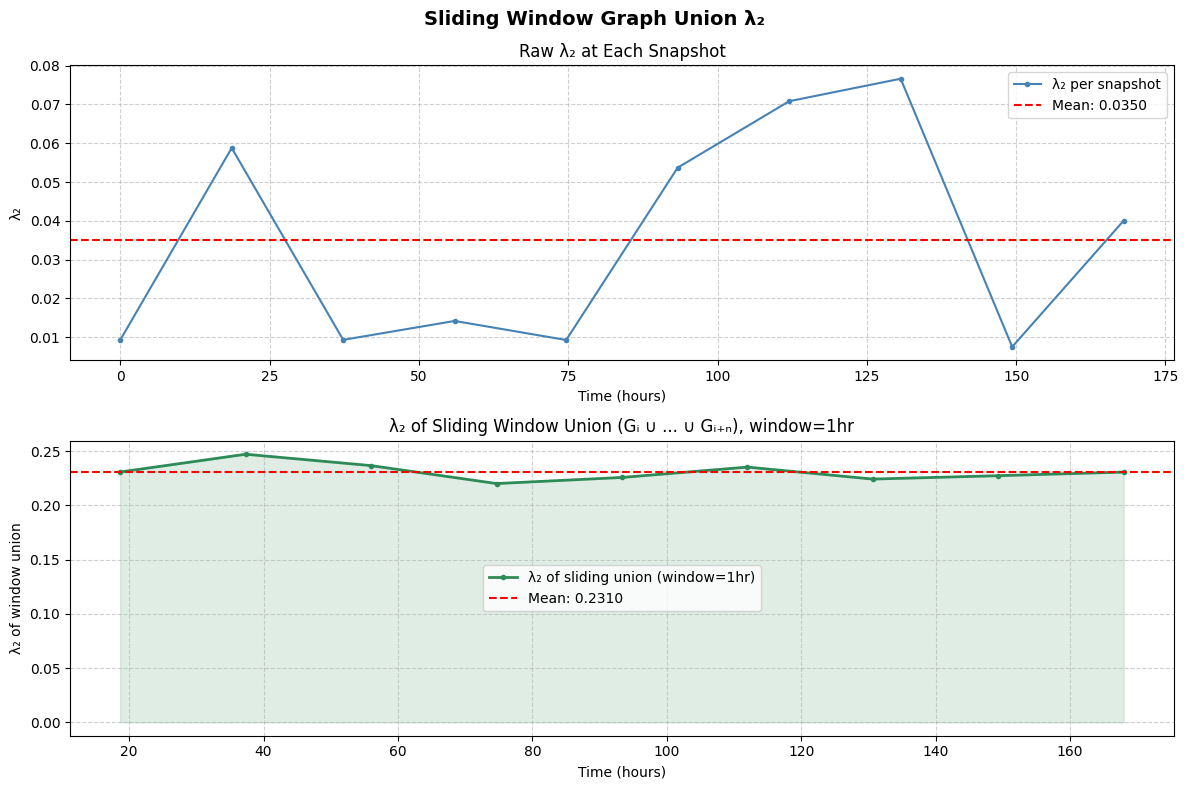


=== Sliding Window Union λ₂ (window=1hr) ===
  Mean:    0.2310
  Min:     0.2202  at t = 74.67 hrs
  Max:     0.2473  at t = 37.33 hrs


In [ ]:
# # ---------------------------------------------------------------
# # Sliding Window Graph Union Lambda_2
# # window_hours controls the size of the sliding window
# # ---------------------------------------------------------------
# window_hours = 1  # hours
# time_step_minutes = times[1] - times[0]
# window_size = max(2, int((window_hours * 60) / time_step_minutes))  # number of graphs per window
# print(f"Time step: {time_step_minutes:.2f} min | Window size: {window_size} snapshots = {window_hours} hr")

# sliding_union_lambda2 = []
# sliding_times = []

# for i in range(len(G_list) - window_size + 1):
#     # Build union of graphs in this window: G_i ∪ G_i+1 ∪ ... ∪ G_i+window_size-1
#     G_window_union = G_list[i].copy()
#     for j in range(1, window_size):
#         G_window_union.add_edges_from(G_list[i + j].edges())

#     sliding_union_lambda2.append(nx.algebraic_connectivity(G_window_union))
#     sliding_times.append(times_hours[i + window_size - 1])  # label at window end
#     print(f"Window [{i}:{i+window_size}] | edges: {G_window_union.number_of_edges()} | λ₂: {sliding_union_lambda2[-1]:.4f}")

# sliding_union_lambda2 = np.array(sliding_union_lambda2)
# sliding_times = np.array(sliding_times)

# # ---------------------------------------------------------------
# # Plot
# # ---------------------------------------------------------------
# fig, axes = plt.subplots(2, 1, figsize=(12, 8))
# fig.suptitle('Sliding Window Graph Union λ₂', fontsize=14, fontweight='bold')

# # --- Plot 1: Raw Lambda_2 per snapshot ---
# axes[0].plot(times_hours, lambda_2_list, color='steelblue', linewidth=1.5,
#              marker='o', markersize=3, label='λ₂ per snapshot')
# axes[0].axhline(np.mean(lambda_2_list), color='red', linestyle='--',
#                 label=f'Mean: {np.mean(lambda_2_list):.4f}')
# axes[0].set_title('Raw λ₂ at Each Snapshot')
# axes[0].set_xlabel('Time (hours)')
# axes[0].set_ylabel('λ₂')
# axes[0].legend()
# axes[0].grid(True, linestyle='--', alpha=0.6)

# # --- Plot 2: Sliding Window Union Lambda_2 ---
# axes[1].plot(sliding_times, sliding_union_lambda2, color='seagreen', linewidth=2,
#              marker='o', markersize=3,
#              label=f'λ₂ of sliding union (window={window_hours}hr)')
# axes[1].fill_between(sliding_times, sliding_union_lambda2, alpha=0.15, color='seagreen')
# axes[1].axhline(np.mean(sliding_union_lambda2), color='red', linestyle='--',
#                 label=f'Mean: {np.mean(sliding_union_lambda2):.4f}')
# axes[1].set_title(f'λ₂ of Sliding Window Union (Gᵢ ∪ ... ∪ Gᵢ₊ₙ), window={window_hours}hr')
# axes[1].set_xlabel('Time (hours)')
# axes[1].set_ylabel('λ₂ of window union')
# axes[1].legend()
# axes[1].grid(True, linestyle='--', alpha=0.6)

# plt.tight_layout()
# # plt.savefig('lambda2_sliding_union.png', dpi=150, bbox_inches='tight')
# plt.show()

# # ---------------------------------------------------------------
# # Summary
# # ---------------------------------------------------------------
# print(f"\n=== Sliding Window Union λ₂ (window={window_hours}hr) ===")
# print(f"  Mean:    {np.mean(sliding_union_lambda2):.4f}")
# print(f"  Min:     {np.min(sliding_union_lambda2):.4f}  at t = {sliding_times[np.argmin(sliding_union_lambda2)]:.2f} hrs")
# print(f"  Max:     {np.max(sliding_union_lambda2):.4f}  at t = {sliding_times[np.argmax(sliding_union_lambda2)]:.2f} hrs")